In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [4]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
import numpy as np

In [5]:
def no_reward_mask_from_pos_idx(pos_idx_array):
    """
    input: int position ([0,1,2,3,...,6])
    output: Give a mask to NN to output float 0 for position "2,3,4".
    """
    pos_idx_array = np.asarray(pos_idx_array).astype(int).ravel()
    return (~np.isin(pos_idx_array, [2, 3, 4])).astype(np.float32)

-1000 train done
1.308788403340012


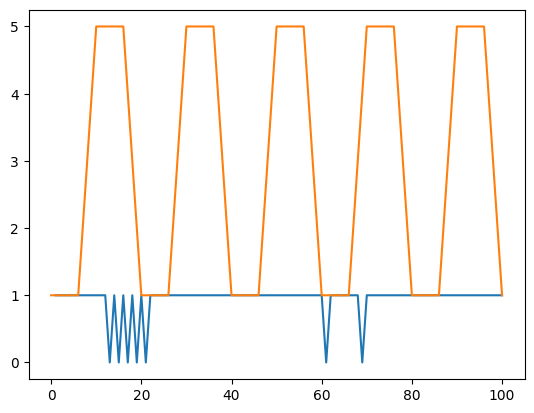

-872 train done
1.020554307961854


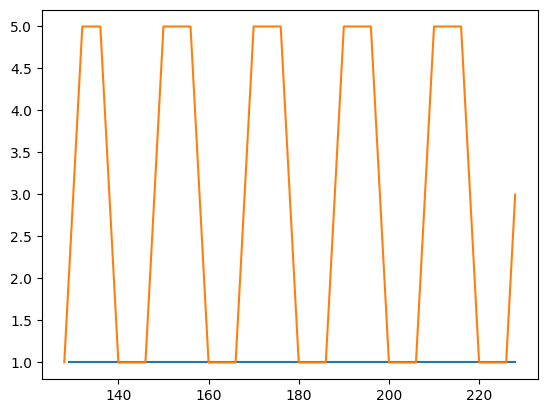

-744 train done
1.0346191990646767


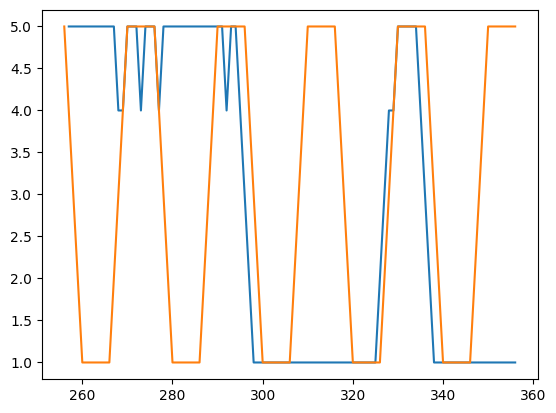

-488 train done
0.7427414019847083


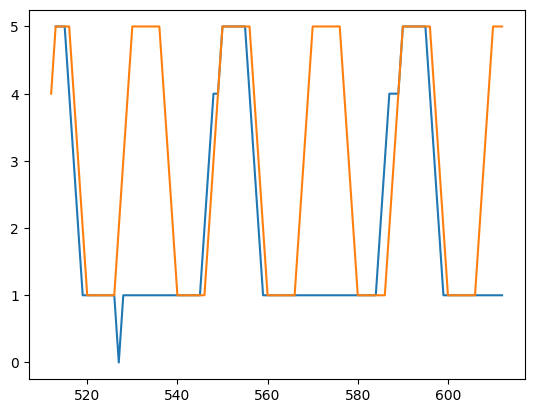

-250 train done
0.9413778947551847


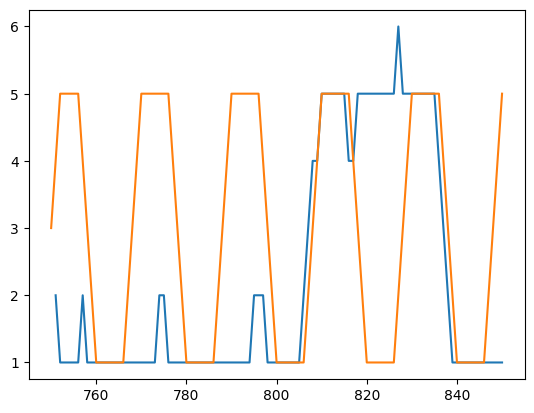

24 train done
0.9622128438154018


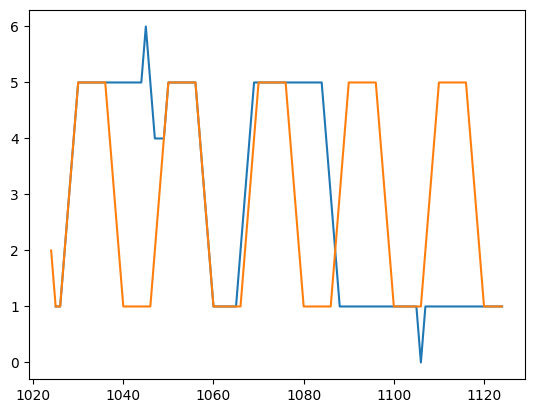

250 train done
0.4888809766021549


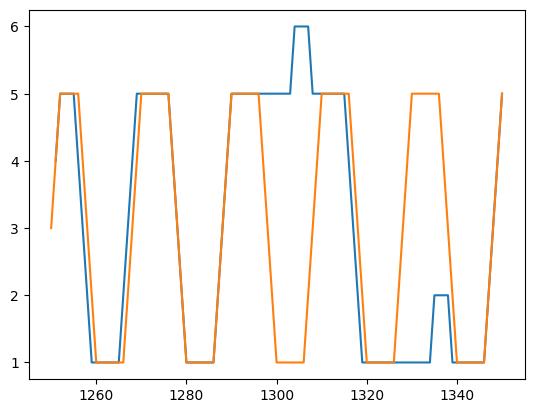

500 train done
0.669786844684628


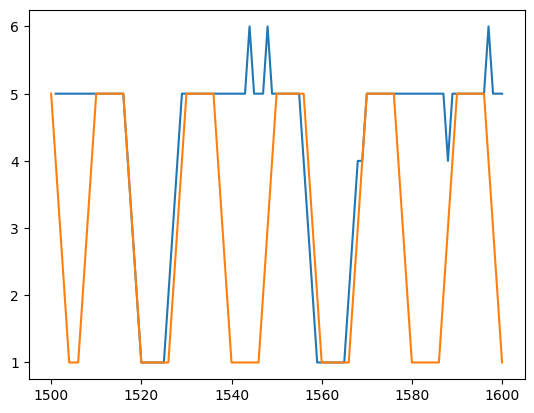

1048 train done
0.004665600000000154


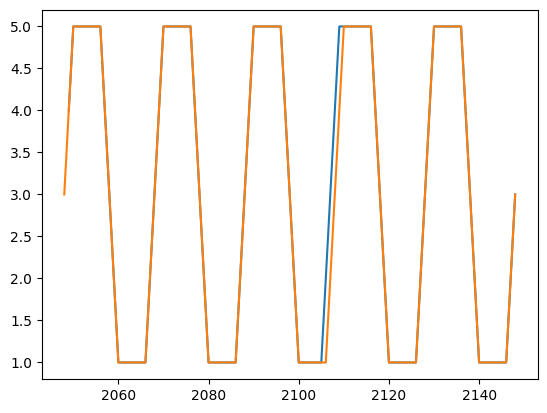

-1000 train done
1.308788403340012


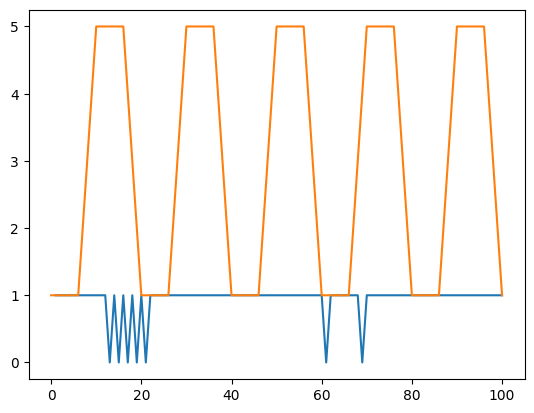

-872 train done
1.0655543079618541


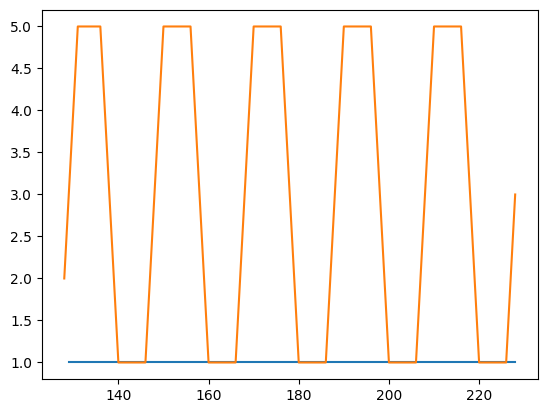

-744 train done
1.165131088736666


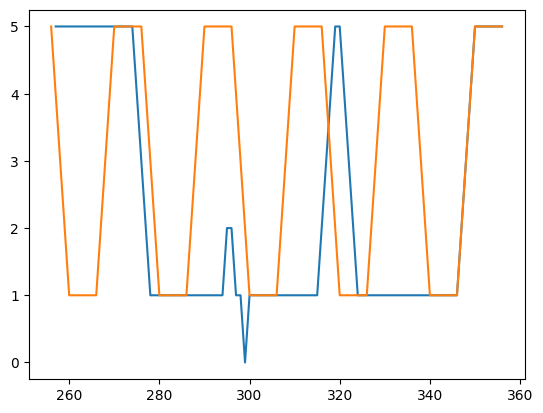

-488 train done
1.0552492690738262


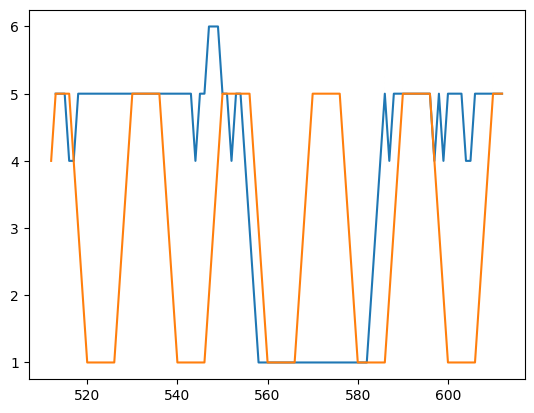

-250 train done
0.9697041744807328


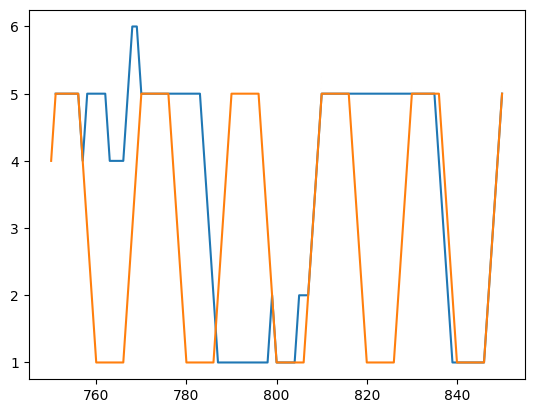

24 train done
0.24218045217529321


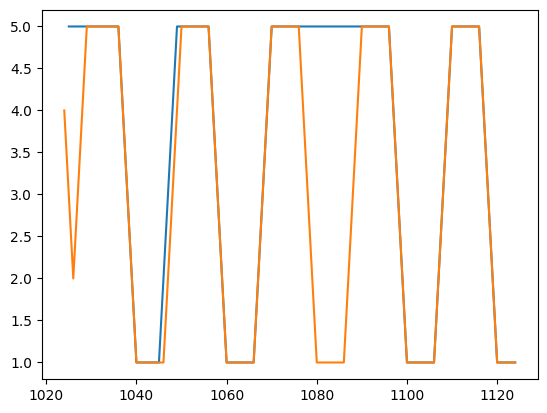

250 train done
0.2590763538951197


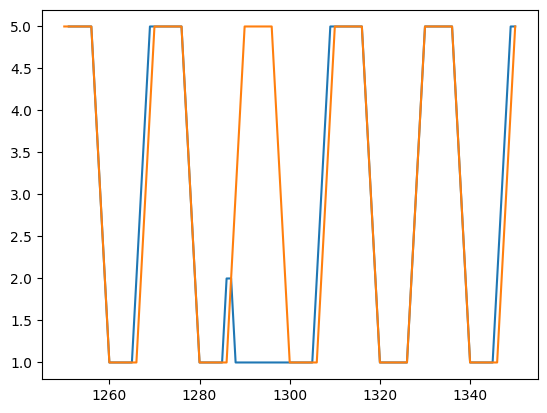

500 train done
0.25151192206301887


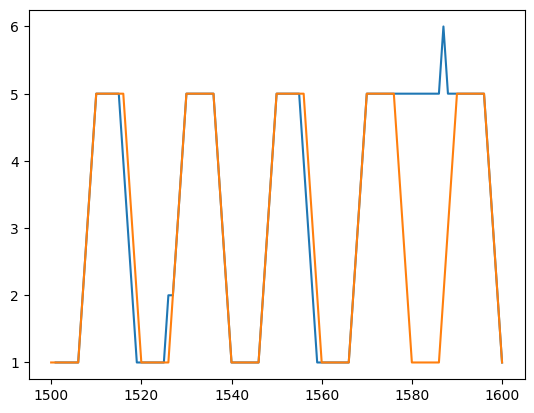

1048 train done
0.24075146352062773


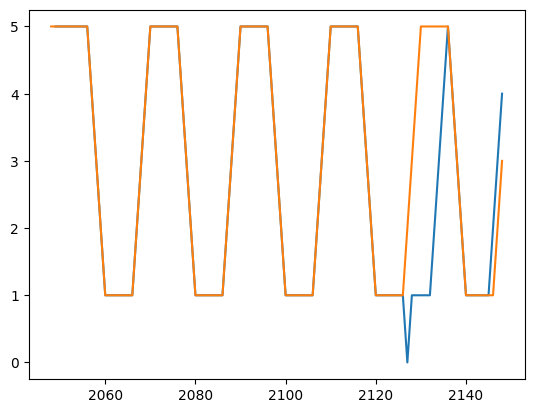

-1000 train done
1.308788403340012


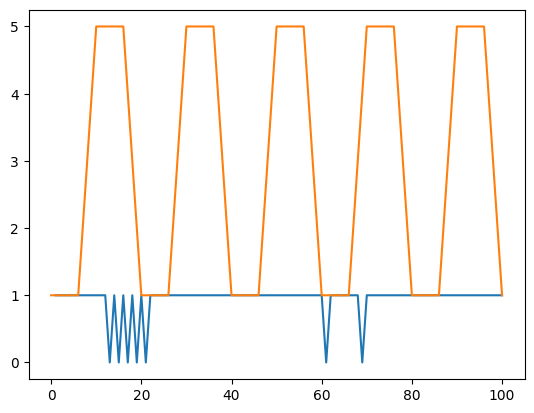

-872 train done
1.2359049349205455


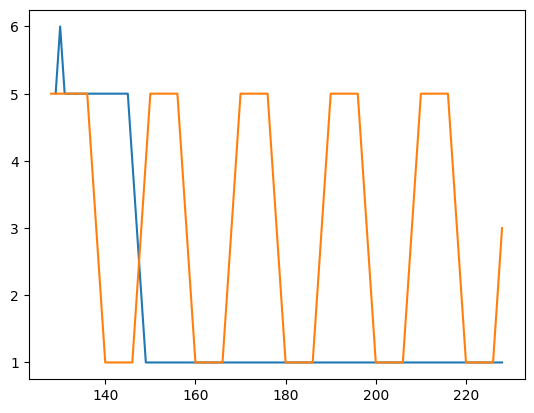

-744 train done
1.2035878486763634


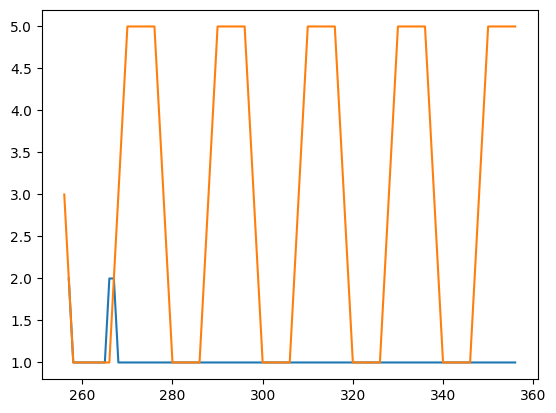

-488 train done
1.1939468421807111


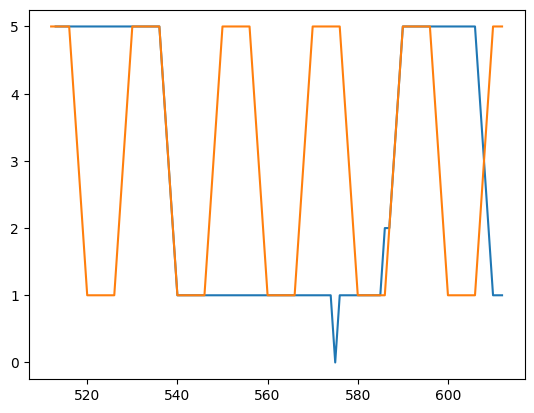

-250 train done
0.9499291832102358


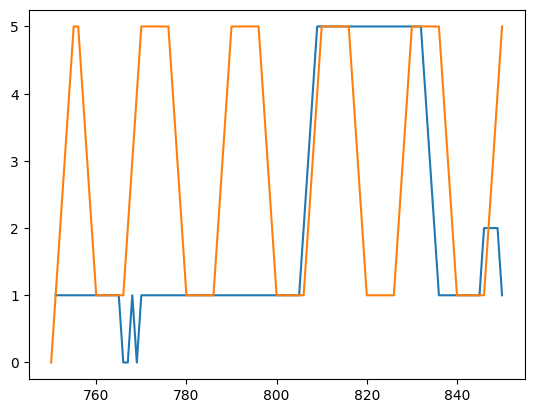

24 train done
0.48903259661760756


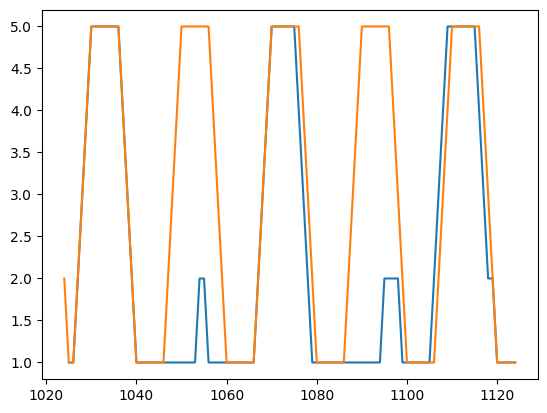

250 train done
0.9575243896422563


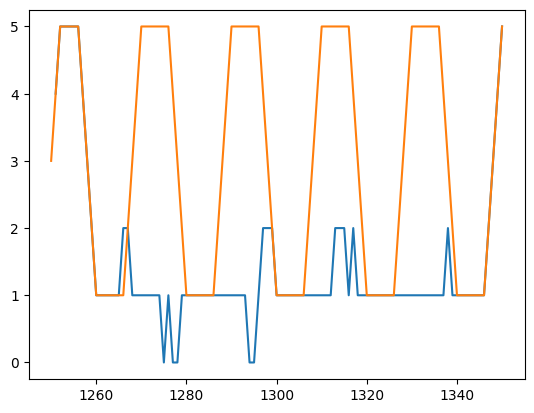

500 train done
0.25440389616392706


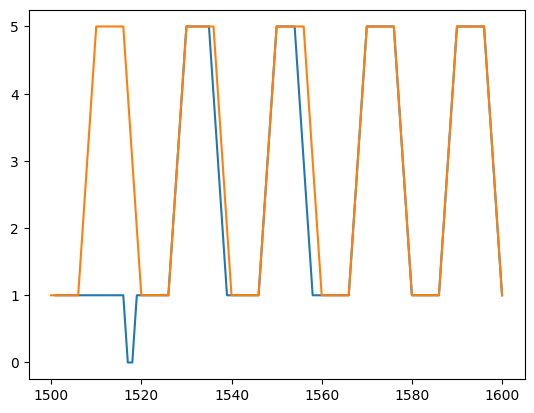

1048 train done
0.47091104101658826


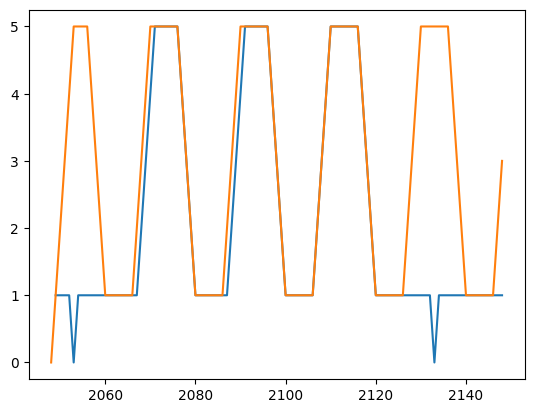

-1000 train done
1.308788403340012


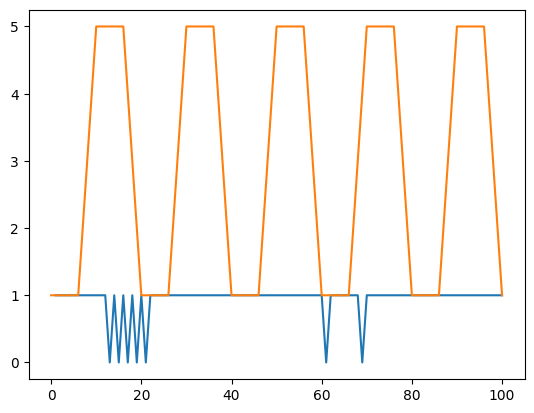

-872 train done
1.0754078533688618


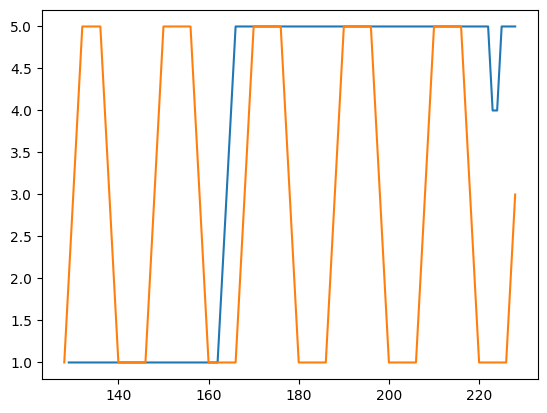

-744 train done
1.173618695568637


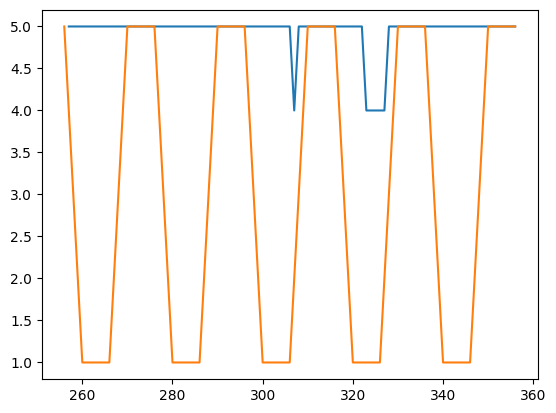

-488 train done
0.9589118516114218


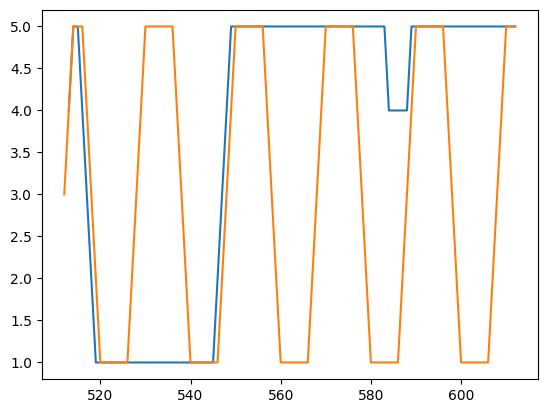

-250 train done
0.39300538585603645


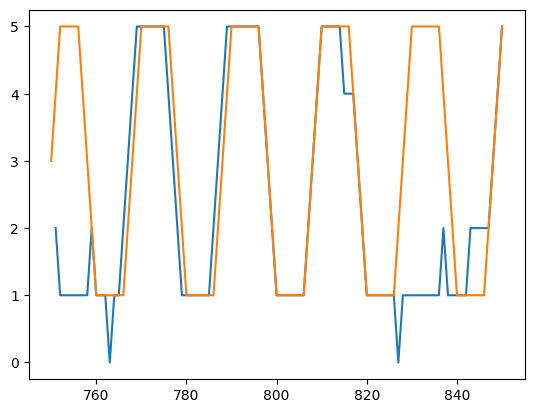

24 train done
0.2608489629981807


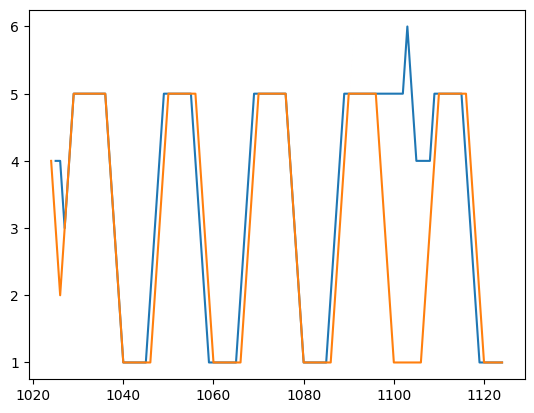

250 train done
0.7644493579716891


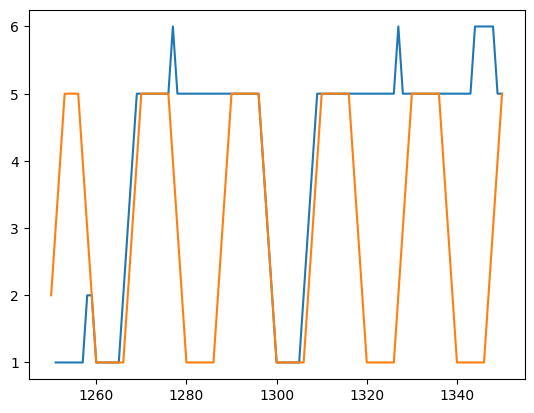

500 train done
0.2467005695214732


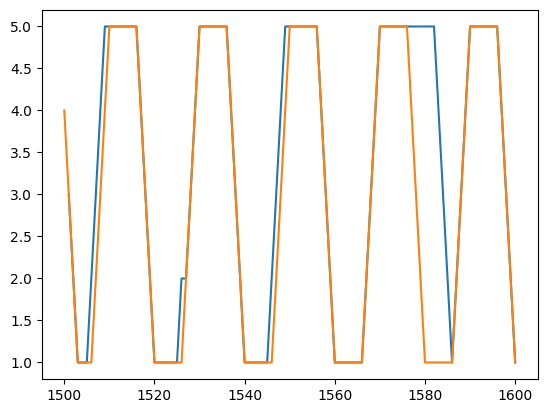

1048 train done
0.4716863586187918


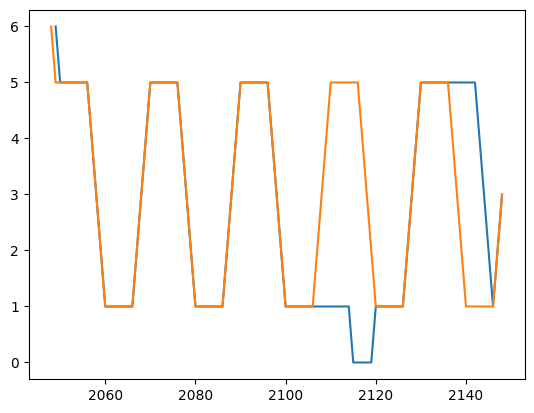

-1000 train done
1.187780690960278


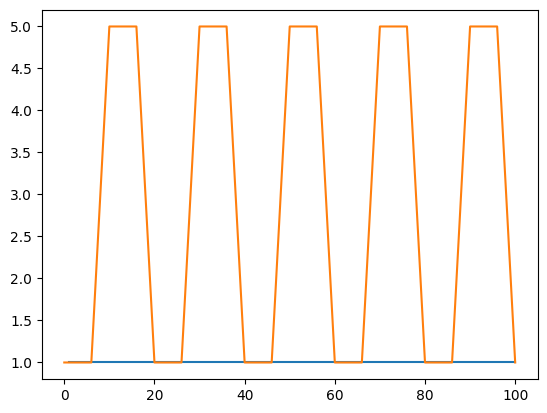

-872 train done
1.0232529388469733


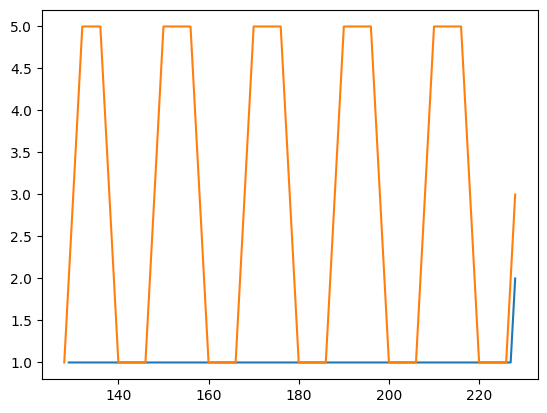

-744 train done
1.21273160455455


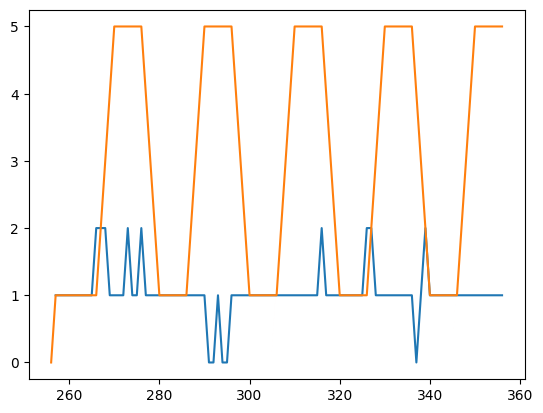

-488 train done
1.1835794188214925


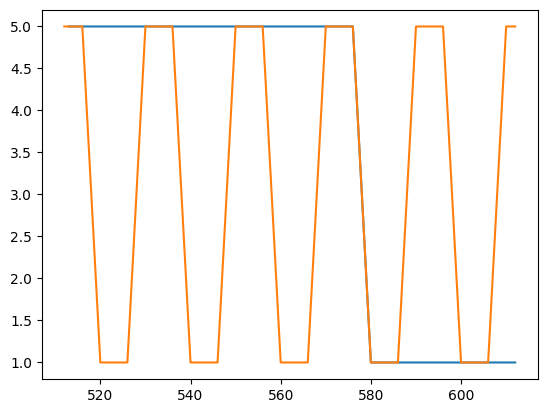

-250 train done
1.2399879496518926


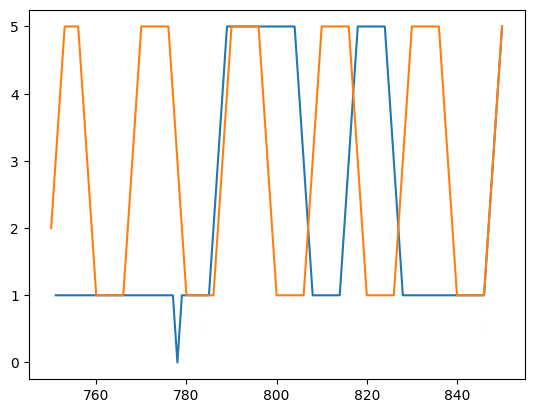

24 train done
0.9628724135112822


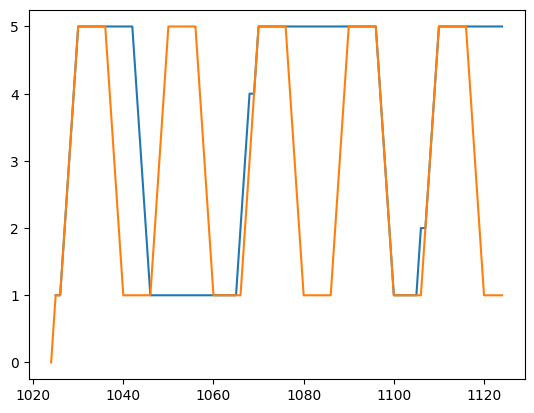

250 train done
0.7297651579137729


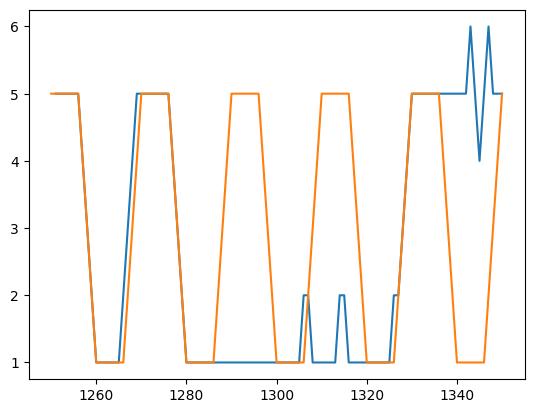

500 train done
0.5237104958474095


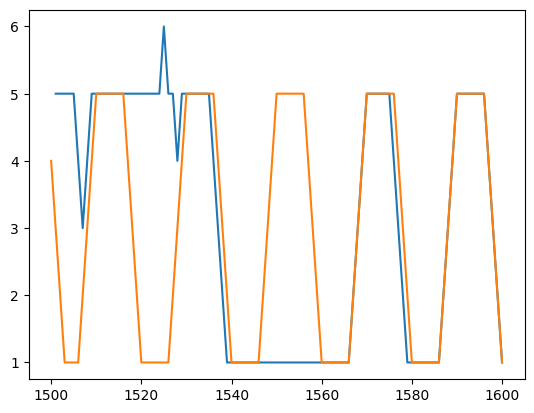

1048 train done
0.5281019585824146


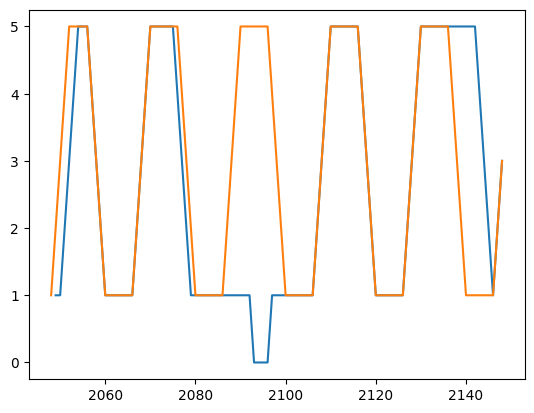

-1000 train done
1.187780690960278


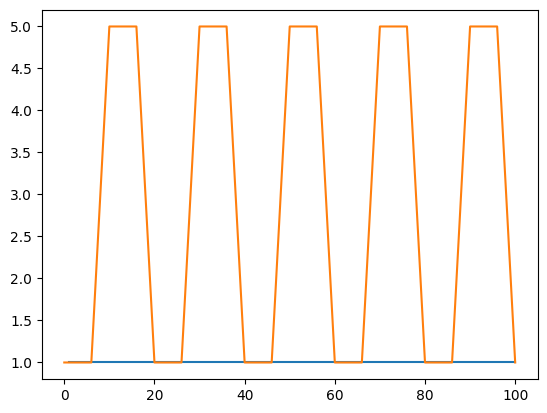

-872 train done
0.9597494877972553


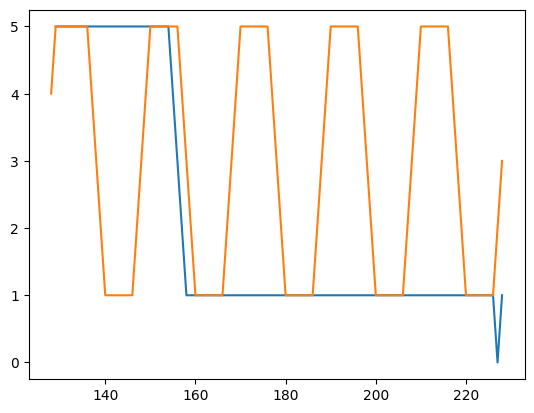

-744 train done
0.856062240924071


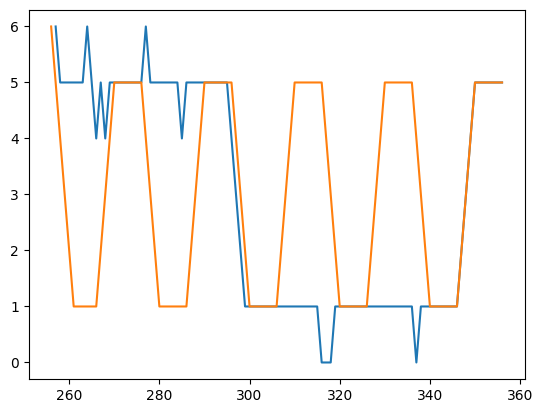

-488 train done
0.981799211609611


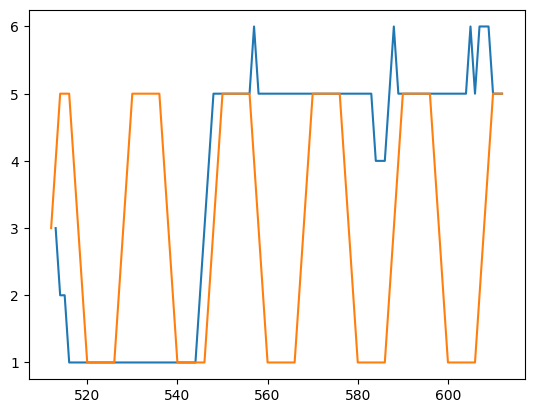

-250 train done
1.187780690960278


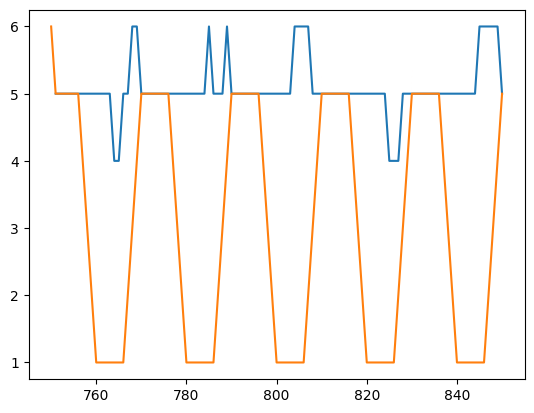

24 train done
0.9706574008812595


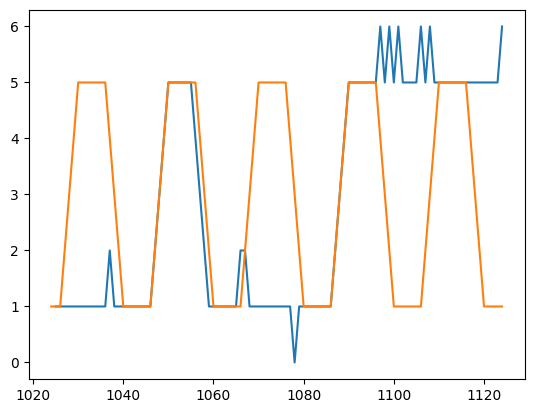

250 train done
0.4965952858962618


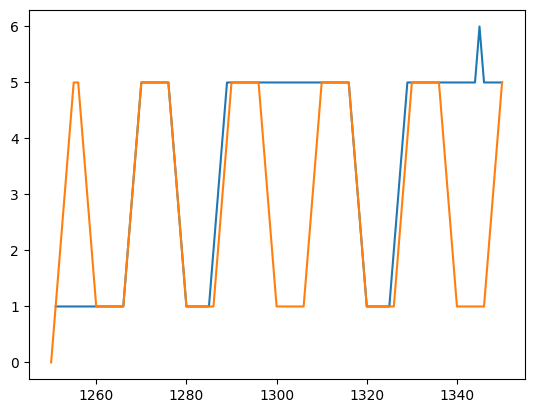

500 train done
0.4091216377407423


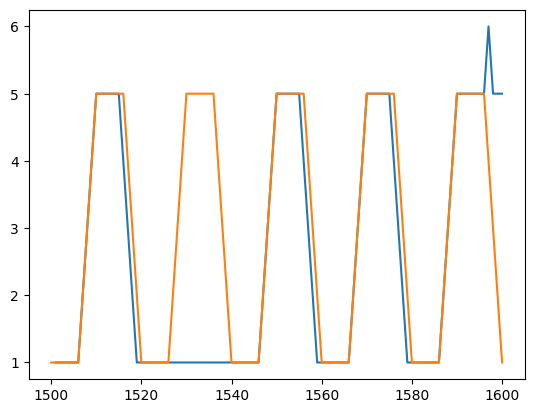

1048 train done
0.4750313495904271


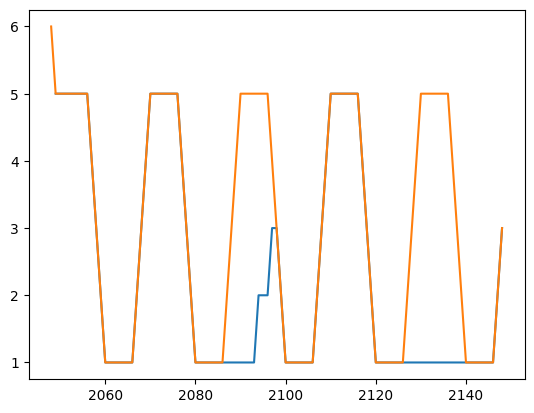

-1000 train done
1.187780690960278


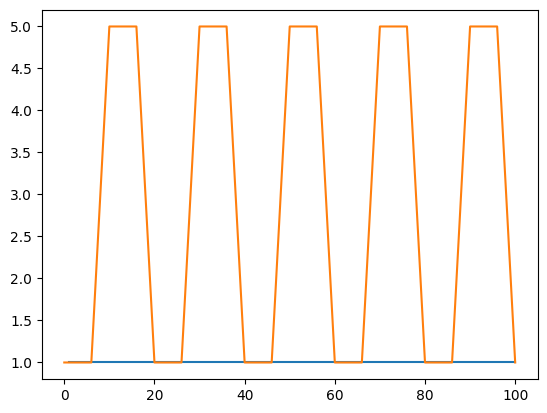

-872 train done
1.0394677716121896


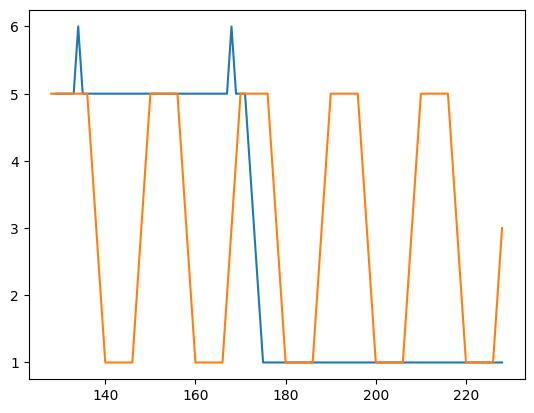

-744 train done
1.4041478948961652


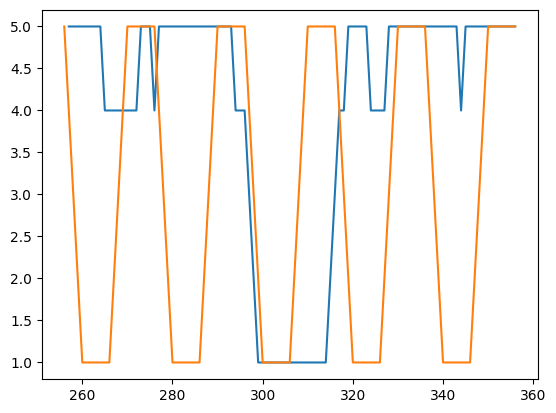

-488 train done
1.1885336004161267


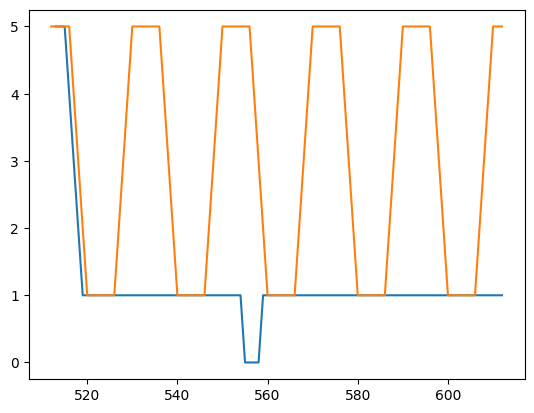

-250 train done
0.9789787747399126


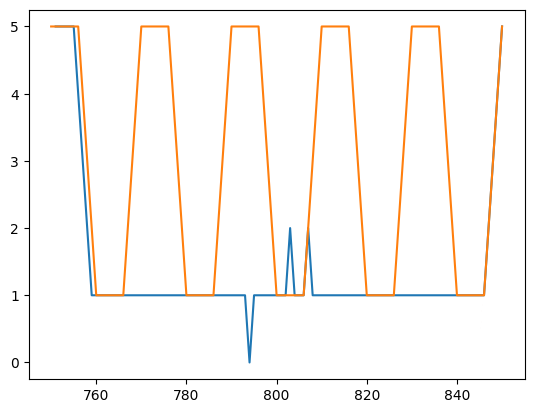

24 train done
0.9512405677099772


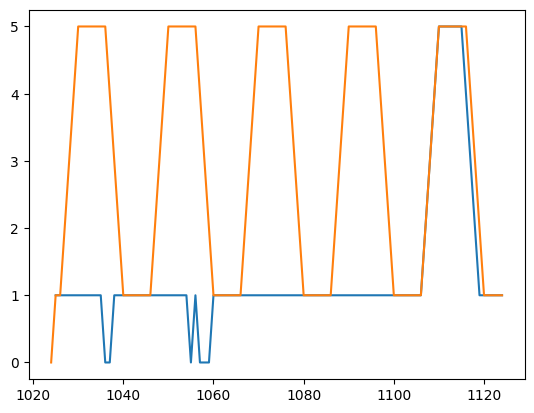

250 train done
0.5075108035855004


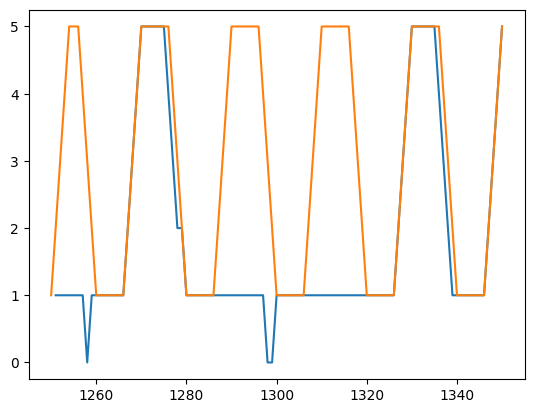

500 train done
0.27182892947109166


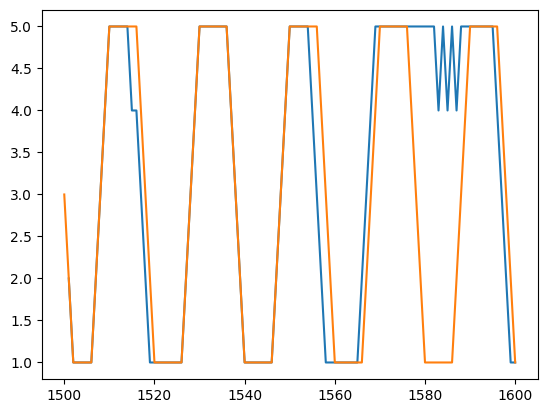

1048 train done
0.23141950723109914


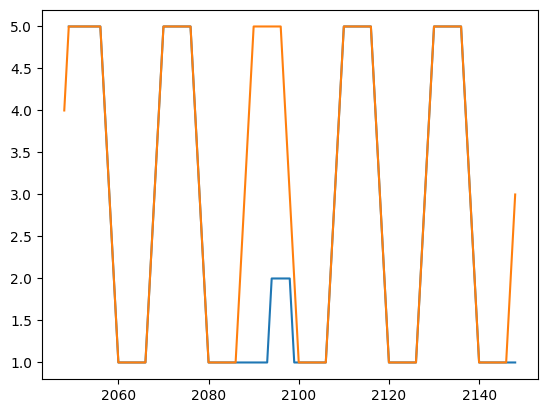

-1000 train done
1.187780690960278


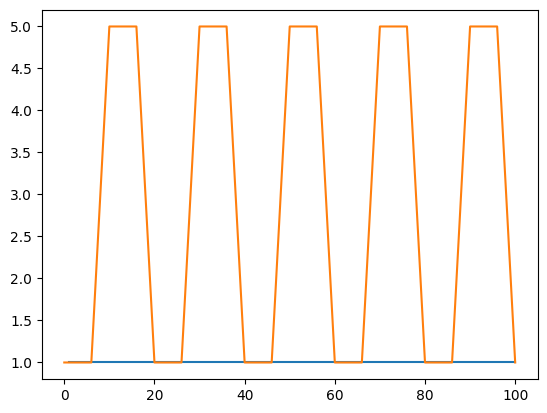

-872 train done
1.115554307961854


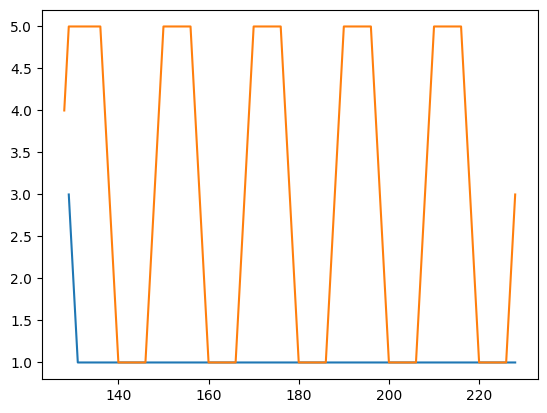

-744 train done
1.1961347349263634


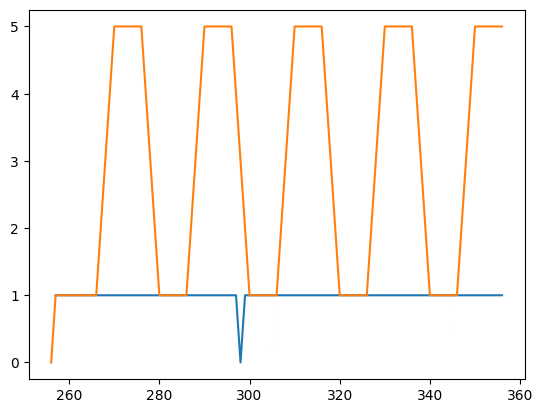

-488 train done
1.201700382943852


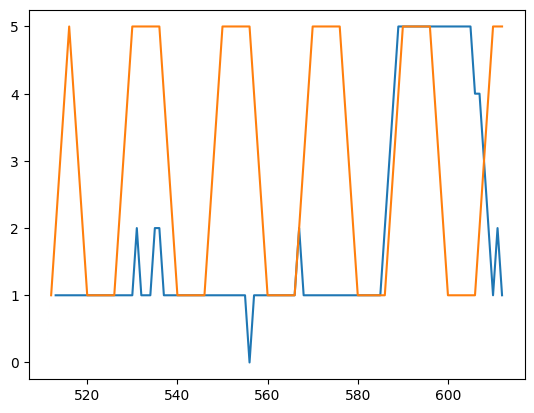

-250 train done
0.9695016345947812


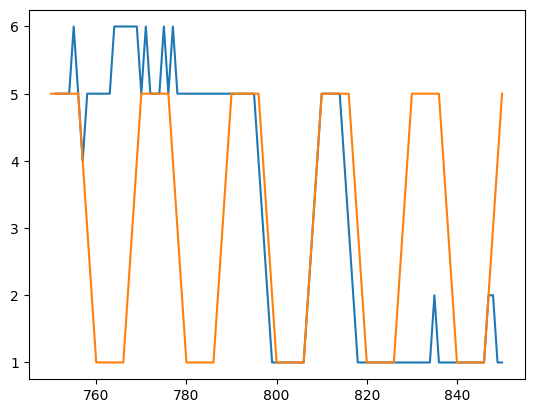

24 train done
0.7712330234333052


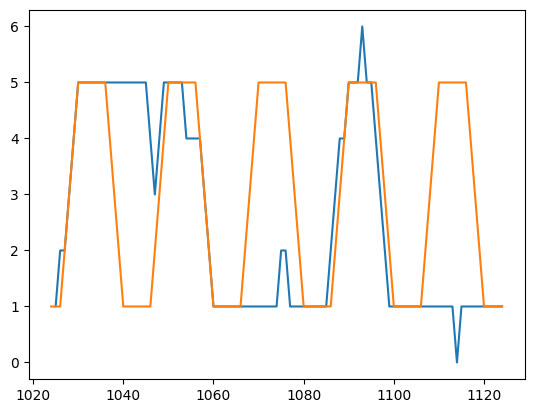

250 train done
0.2567897097250335


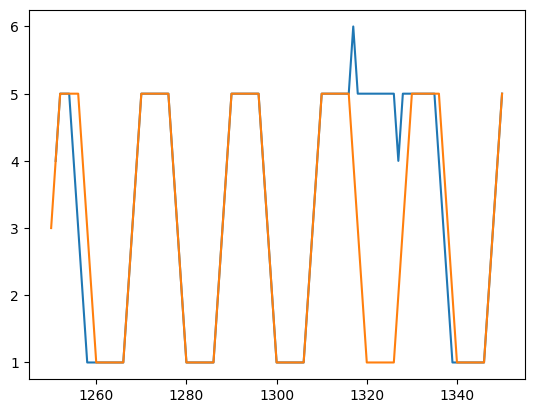

500 train done
0.712969140203497


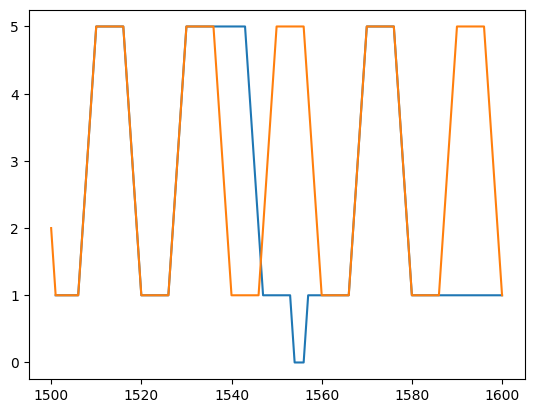

1048 train done
0.6888466610706274


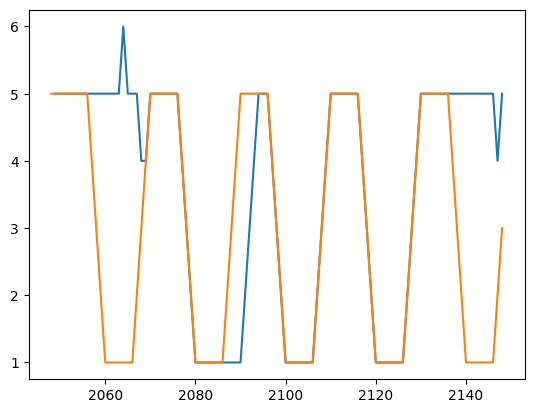

-1000 train done
1.187780690960278


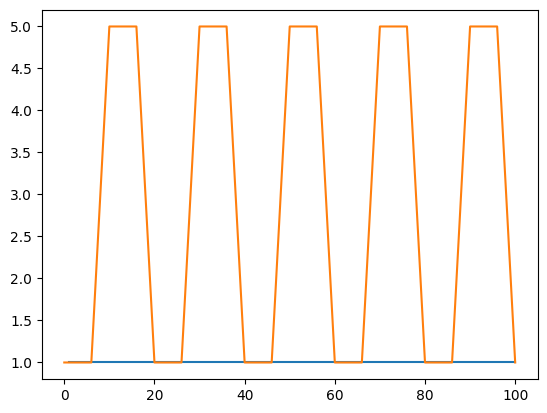

-872 train done
1.0733303079618546


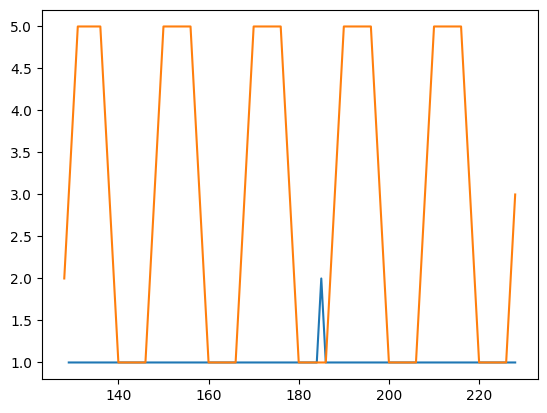

-744 train done
1.181083655568649


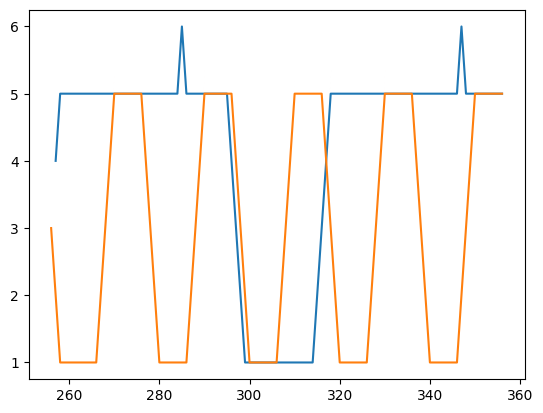

-488 train done
1.1914725244166158


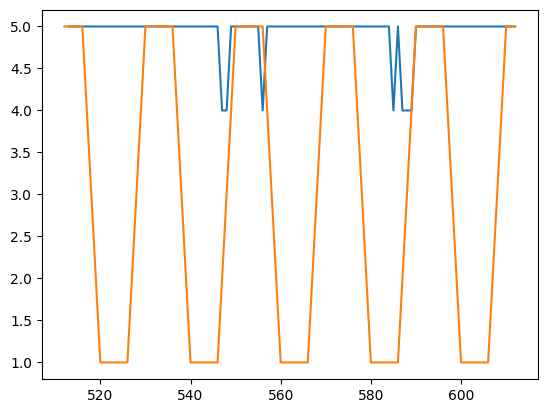

-250 train done
0.7037976943767004


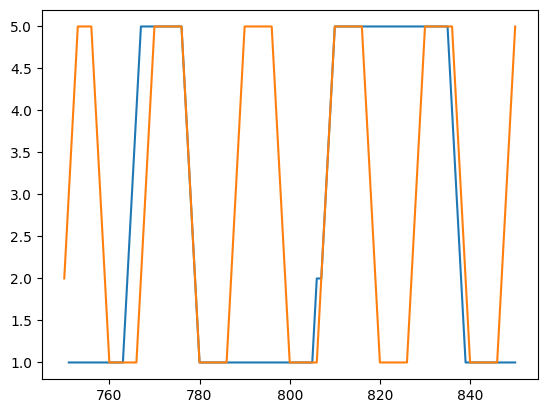

24 train done
0.489032617397099


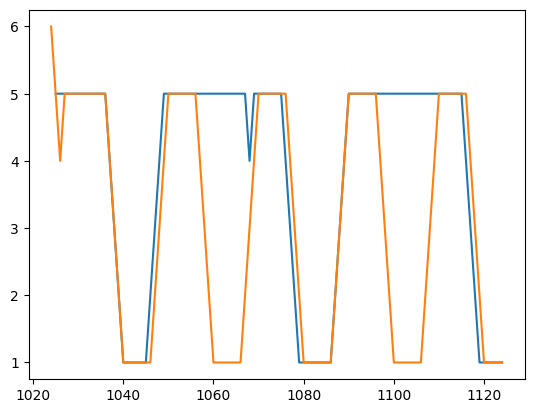

250 train done
0.4829192458035644


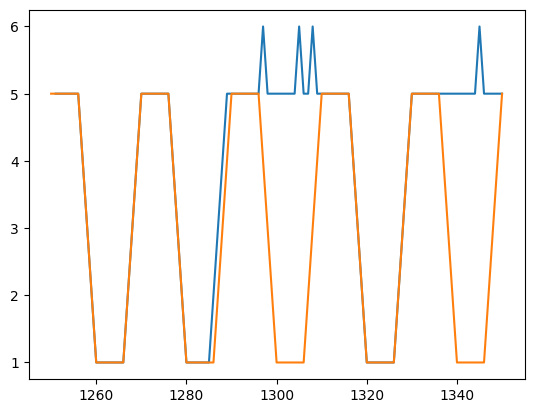

500 train done
0.6517909199329986


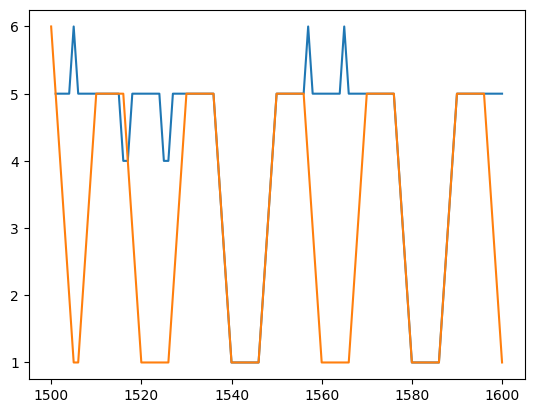

1048 train done
0.020250000000000056


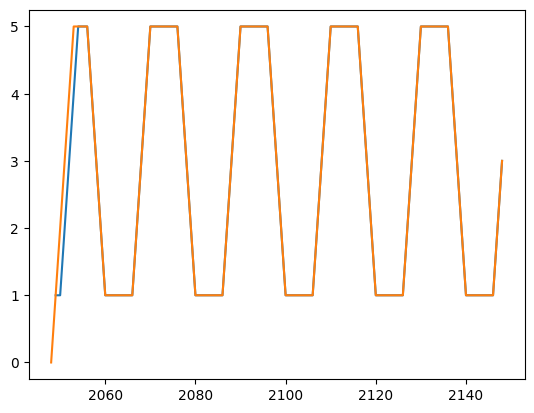

-1000 train done
1.187780690960278


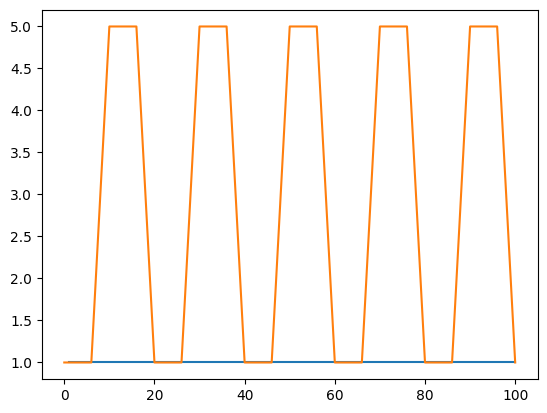

-872 train done
1.115554307961854


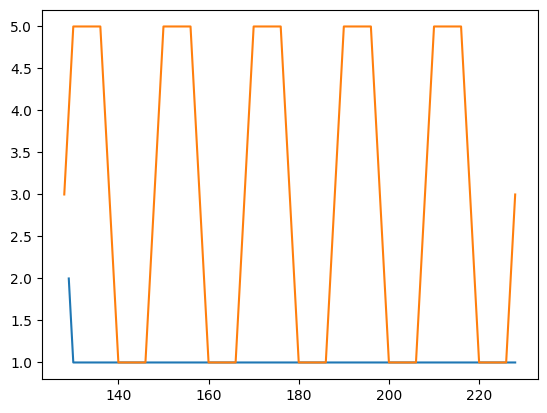

-744 train done
1.1989359189532853


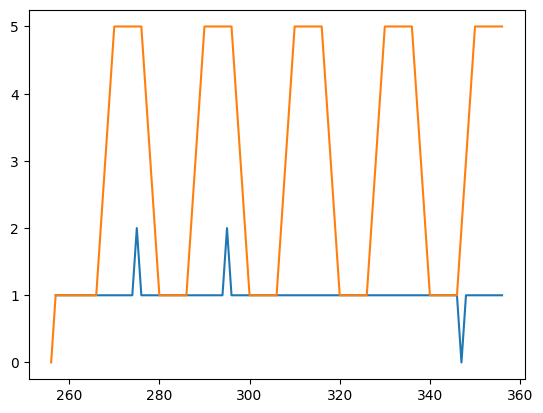

-488 train done
0.9754337358309257


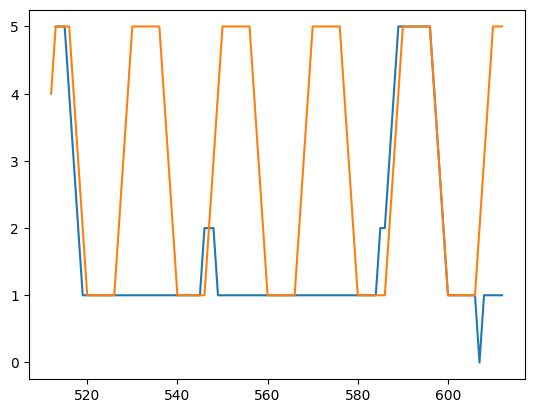

-250 train done
0.9646687747399127


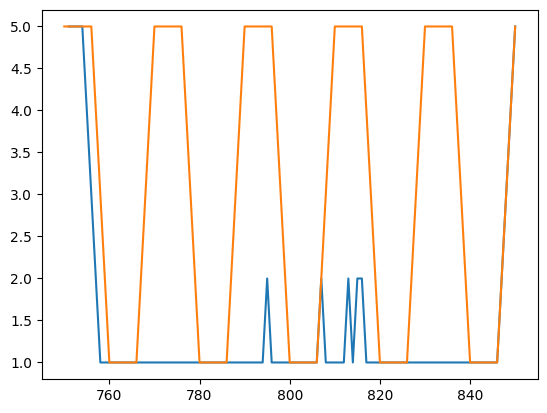

24 train done
0.5094954151710346


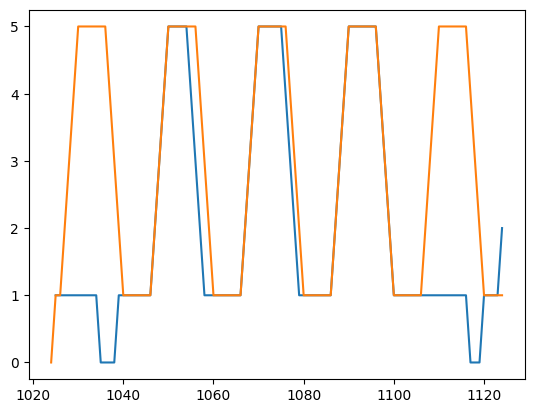

250 train done
0.05143763451264505


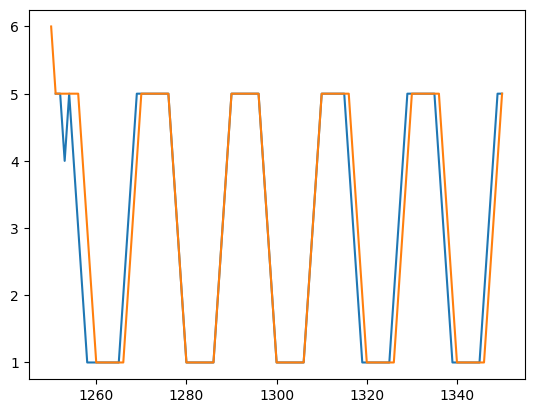

500 train done
0.24694579389549942


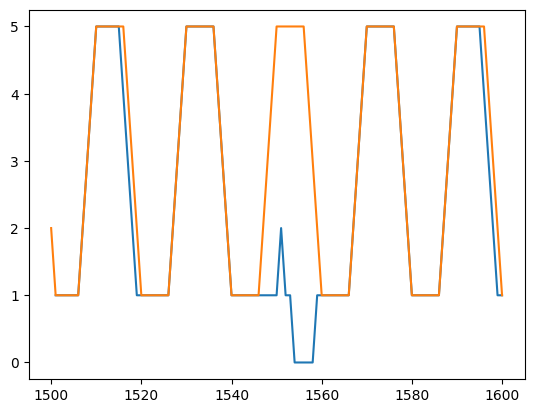

1048 train done
0.23927309182966183


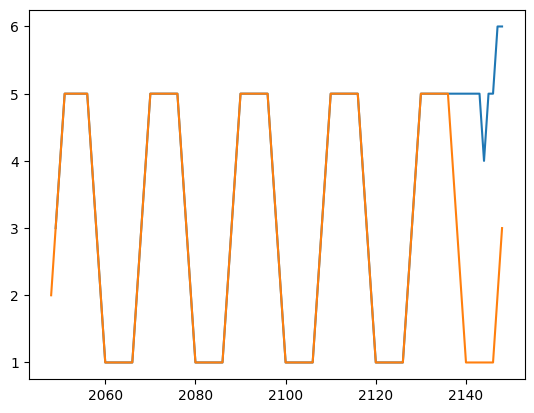

In [8]:
gamma = 0.5 
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
## Onehot Encoding
Ts = [0]+[128,256,512]+[750]+[1024,1250,1500,2048]

for rep in range(10):
    for t_prime in [7]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515 + rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])        
        for T in Ts:
            if T == 0:
                X_train = new_state_oh[:2,:]
                Y_train = irewards[:2]
                rf = MLPRegressor(
                    hidden_layer_sizes=(128, 128),  #  MLP Layer structure
                    solver='adam',
                    learning_rate_init=1e-2,
                    max_iter=5000,
                    random_state=42,
                    early_stopping=False,           
                    verbose=False
                )
                rf.fit(X_train, Y_train)
            else:
                X_train = new_state_oh[:T,:]
                Y_train = irewards[:T]
                rf = MLPRegressor(
                    hidden_layer_sizes=(128, 128),  #  MLP Layer structure
                    solver='adam',
                    learning_rate_init=1e-2,
                    max_iter=5000,
                    random_state=42,
                    early_stopping=False,           
                    verbose=False
                    )
                rf.fit(X_train, Y_train)
            print(T-1000,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf.predict(features)

                # # Compute instantaneous rewards
                # for i, row in df_all_paths.iterrows():
                #     for t in np.arange(t_prime+1):
                #         cand = row[f"t={T+delta_t+t}"]
                #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
                #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
                #         irewards_pred[i, t] = rf.predict(features)[0]

                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                # Extract rewards from second column onward (t=1 to t=T)
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(1, t_prime+1)

                # Compute discounted total reward per path
                discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            #print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../results/PAFM/NN/NN_onehot_w_lookahead_t0_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )